Ejercicio 2 - TS1

En primer lugar se importaron las librerias necesarias y se definieron las variables. 
Se definio la frecuencia de muestreo $fs$ en 10kHz.
Para el caso xa se tomo una frecuencia angular $w0$ de $pi \times 2000 \text{ rad/s}$ ,la cual al discretizarse con $fs$, la frecuencia digital resultante es:$\omega_0 = \frac{w_0}{f_s} = \frac{2000\pi}{10000} = 0.2\pi \text{ rad/muestra}$. Esto corresponde a un período digital de: $T = \frac{2\pi}{\omega_0} = \frac{2\pi}{0.2\pi} = 10 \text{ muestras}$, pusiednose así visulaizar 10 ciclos de la cosenoidal al tomar 100 muestras (Na = 100), y evitando así los efectos de borde de la convolución en python. Además, se cumple el teorema de muestreo de Nyquist, ya que $f_s = 10000 \text{ Hz} \gg 2 \cdot \frac{w_0}{2\pi} = 2000 \text{ Hz}$. 
Para las señales xb y xc, al tratarse de señales finitas en el tiempo, se utilizaron 15 muestras (N=15), para la cual las señales llegan a pasar por el filtro (respuesta al impulso). 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:

# variables
Na=100
N = 15
fs = 10000
w0 = 2000*np.pi

n = np.arange(N)
na = np.arange(Na)


In [73]:
# Señales
# Respuesta al impulso (h)
#para b y c 
h = np.zeros(N)
h[0] = 1
h[4] = -1

#para a
ha = np.zeros(Na)
ha[0] = 1
ha[4] = -1

# Señales de entrada x

#a
xa = np.cos(w0 * na / fs)

#b
#no defino la parte negativa porque es cero, tomo desde 0 a 100
xb = 0.5**n

#c
#aca si necesito parte de la negativa porque es diferente de cero
nc= np.arange(-2,N-2)
xc=np.where((nc >= -1) & (nc < 2), 1, 0)

In [74]:
#Convoluciones
# modo 'full' devuelve una longitud de len(h) + len(x) - 1 

#a
n_conva = np.arange(len(ha)+len(xa)-1)
conva = np.convolve(ha, xa, mode='full')

#b

convb =np.convolve(h, xb, mode='full')
n_convb = np.arange(len(h)+len(xb)-1)

#c
convc= np.convolve(h, xc, mode='full')
n_convc = np.arange(-2, len(convc)-2)

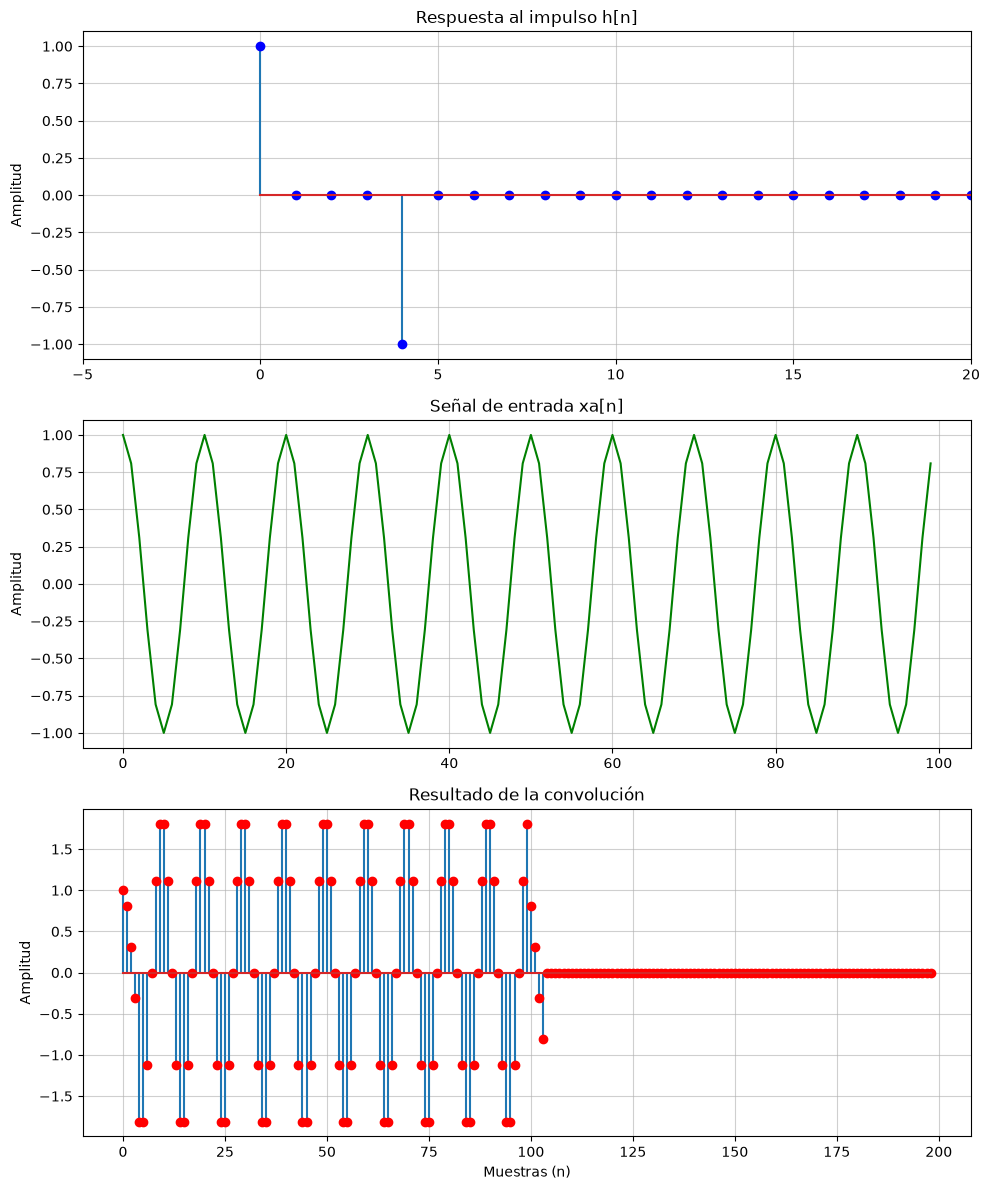

In [81]:
# graficos
#a
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

ax1.stem(na, ha, markerfmt='bo')
ax1.set_title('Respuesta al impulso h[n]')
ax1.set_ylabel('Amplitud')
ax1.grid(True, alpha=0.6)
ax1.set_xlim(-5, N + 5)

ax2.plot(na, xa,  color='g')
ax2.set_title('Señal de entrada xa[n]')
ax2.set_ylabel('Amplitud')
ax2.grid(True, alpha=0.6)

ax3.stem(n_conva, conva, markerfmt='ro')
ax3.set_title('Resultado de la convolución')
ax3.set_ylabel('Amplitud')
ax3.set_xlabel('Muestras (n)')
ax3.grid(True, alpha=0.6)


plt.tight_layout()
plt.show()


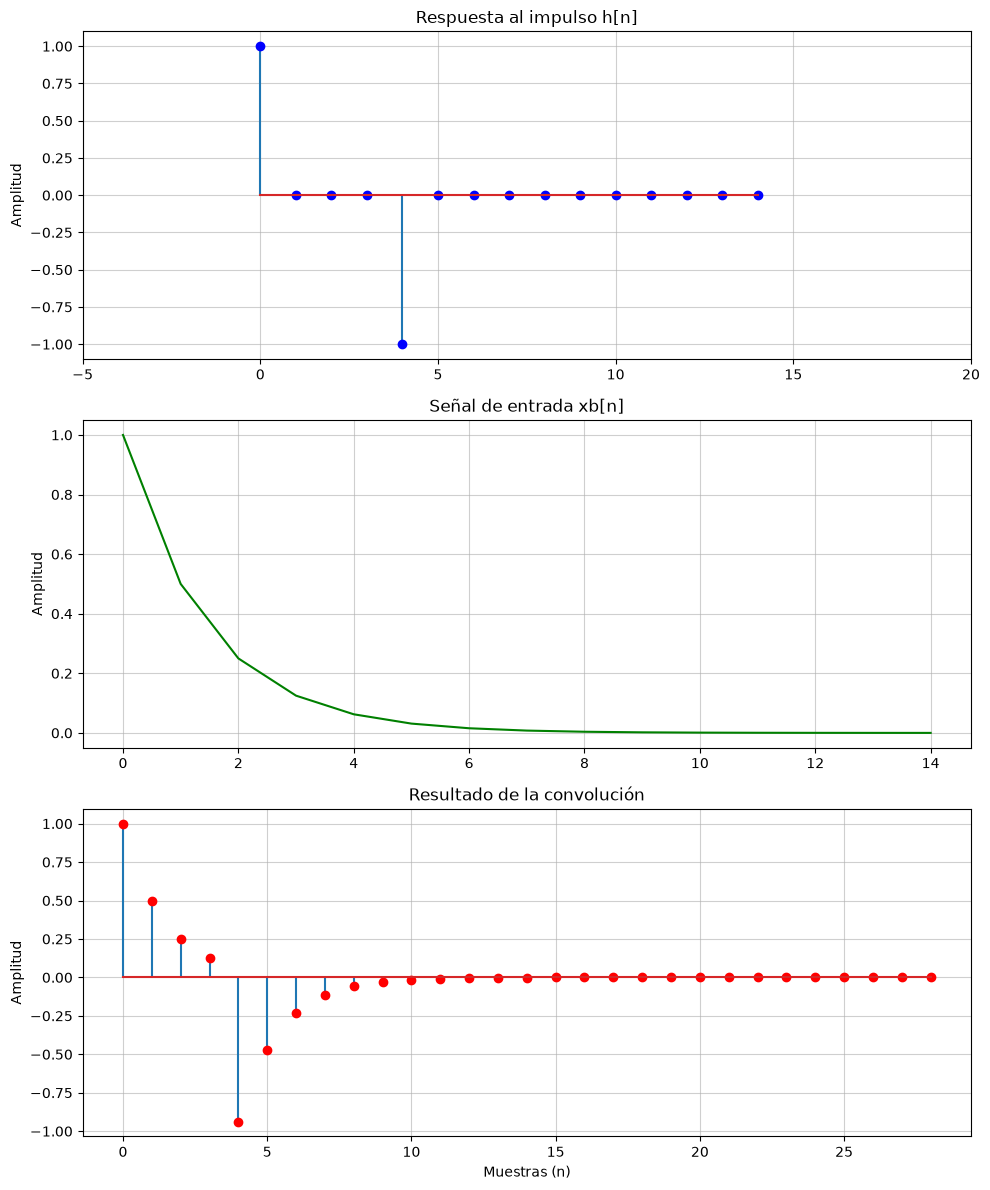

In [82]:
#b
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

ax1.stem(n, h, markerfmt='bo')
ax1.set_title('Respuesta al impulso h[n]')
ax1.set_ylabel('Amplitud')
ax1.grid(True, alpha=0.6)
ax1.set_xlim(-5, N + 5)

ax2.plot(n, xb, color='g')
ax2.set_title('Señal de entrada xb[n]')
ax2.set_ylabel('Amplitud')
ax2.grid(True, alpha=0.6)

ax3.stem(n_convb, convb, markerfmt='ro')
ax3.set_title('Resultado de la convolución')
ax3.set_ylabel('Amplitud')
ax3.set_xlabel('Muestras (n)')
ax3.grid(True, alpha=0.6)


plt.tight_layout()
plt.show()


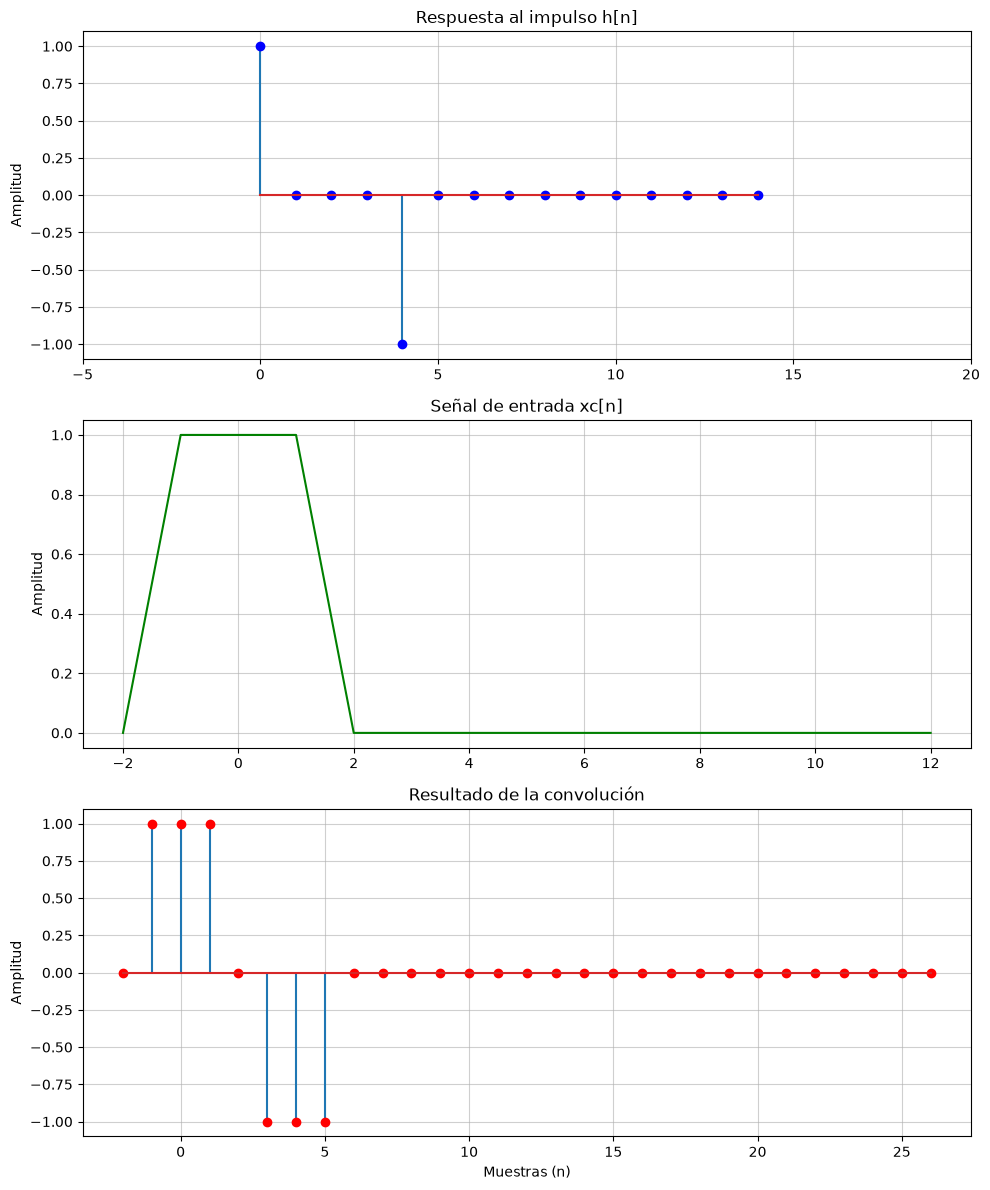

In [83]:
#c
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

ax1.stem(n, h, markerfmt='bo')
ax1.set_title('Respuesta al impulso h[n]')
ax1.set_ylabel('Amplitud')
ax1.grid(True, alpha=0.6)
ax1.set_xlim(-5, N + 5)

ax2.plot(nc, xc, color='g')
ax2.set_title('Señal de entrada xc[n]')
ax2.set_ylabel('Amplitud')
ax2.grid(True, alpha=0.6)

ax3.stem(n_convc, convc, markerfmt='ro')
ax3.set_title('Resultado de la convolución')
ax3.set_ylabel('Amplitud')
ax3.set_xlabel('Muestras (n)')
ax3.grid(True, alpha=0.6)


plt.tight_layout()
plt.show()

Para las tres convoluciones se espera un transitorio inicial y uno final de 4 muestras cada uno, que representan lo que tarda la respuesta al impulso en entrar completamente en la señal.
Para la cosenoidal la salida el resultado otra cosenoide con la misma frecuencia pero diferente amplitud y fase. En base a lo calculado a mano se habia hallado $$ y_a[n] = 2 \cdot \sin(2w_0 T_s) \cdot \cos\left(w_0 \cdot n \cdot T_s + \frac{\pi}{2} - 2w_0 T_s\right) $$, para el caso puntual de $w0$ = $pi \times 2000 \text{ rad/s}$ y $fs$ en 10kHz queda: $$ 1.9 \cdot \cos\left(w_0 \cdot n \cdot T_s + \frac{1}{10}\pi\right) $$ Lo cual implica una amplitud de 1.9 y un desfasaje en 0.1π, cosnistente con lo que se ve graficamente, además del regimen transitorio donde en las primeras 4 muestras, la salida no alcanza la amplitud de régimen permanente. 
Para la exponencial decreciente (xb), las primeras 4 muestras la salida es igual a la señal de entrada. En n = 4 se produce una inversión de signo, debido a que el termino negativo de h "entra" en la señal.
Por último, para xc su convolución da como resultado dos pulsos rectangulares de igual duración y magnitud pero en dirección opuesta. Donde el bloque positivo es el correspondiente al término $\delta[n]$ de $h[n]$., y el bloque negativo a el término $-\delta[n-4]$ de $h[n]$.
Con esto se pudieron verificar los resultados obtenidos analíticamente